# Notebook 03 — Customer RFM

## Brazilian E-Commerce Public Dataset by Olist

### Objetivo executivo

Transformar o histórico transacional em uma visão acionável de **valor, recorrência e risco de relacionamento** dos clientes. O notebook constrói uma dimensão RFM no nível de `customer_unique_id`, mede concentração de receita, separa clientes de compra única de recorrentes e traduz os resultados em segmentos úteis para CRM, retenção e alocação de investimento.

### Perguntas de negócio

1. Qual é o perfil de valor e recorrência da base de clientes?
2. Quantos clientes efetivamente recompram dentro do período observado?
3. Quanto da receita depende de clientes recorrentes e dos clientes de maior valor?
4. Quais segmentos RFM devem ser priorizados para retenção, expansão e reativação?
5. Como o mix de meios de pagamento varia entre segmentos de clientes?
6. Quais outputs devem alimentar as análises de recompra, coorte e previsão?

> **Unidade de análise:** `customer_unique_id`. O campo `customer_id` identifica o cadastro associado a cada pedido e pode mudar entre compras do mesmo consumidor; por isso, não deve ser usado para medir recorrência.


## 1. Configuração e carregamento

O notebook utiliza `orders_base.csv`, produzido no Notebook 01 com uma linha por pedido e pagamentos/itens previamente agregados. Essa arquitetura evita dupla contagem de receita ao juntar tabelas de granularidades diferentes.

A análise principal considera apenas pedidos **delivered**, com cliente e data de compra válidos.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
orders_base_path = PROCESSED_DIR / "orders_base.csv"

if not orders_base_path.exists():
    raise FileNotFoundError(
        "orders_base.csv não encontrado. Execute o Notebook 01 antes do Notebook 03."
    )

orders_base = pd.read_csv(orders_base_path)
orders_base["order_purchase_timestamp"] = pd.to_datetime(
    orders_base["order_purchase_timestamp"], errors="coerce"
)

required = {
    "order_id", "customer_unique_id", "order_status",
    "order_purchase_timestamp", "payment_value"
}
missing = required.difference(orders_base.columns)
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes em orders_base: {sorted(missing)}")

print(f"orders_base: {orders_base.shape[0]:,} linhas x {orders_base.shape[1]} colunas")


orders_base: 99,441 linhas x 16 colunas


In [2]:
display(orders_base.head())

display(
    orders_base[[
        "order_id", "customer_unique_id", "order_status",
        "order_purchase_timestamp", "payment_value"
    ]].isna().sum().to_frame("missing")
)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value,payment_count,item_count,product_value,freight_value,distinct_products,distinct_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,38.71,3.00,1.00,29.99,8.72,1.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,141.46,1.00,1.00,118.70,22.76,1.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,179.12,1.00,1.00,159.90,19.22,1.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,72.20,1.00,1.00,45.00,27.20,1.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,28.62,1.00,1.00,19.90,8.72,1.00,1.00


,missing
order_id,0
customer_unique_id,0
order_status,0
order_purchase_timestamp,0
payment_value,1


## 2. Universo analítico e data de referência

O RFM deve ser interpretado como um **snapshot**. A data de referência é definida como um dia após a última compra entregue observada. Assim, Recency mede quantos dias se passaram desde a última compra até um ponto fixo e reproduzível.

`payment_value` é o valor consolidado pago no pedido. Valores ausentes são tratados como zero apenas após a filtragem de pedidos válidos, e valores negativos são excluídos como proteção de qualidade.


In [3]:
rfm_orders = orders_base.loc[
    orders_base["order_status"].eq("delivered")
    & orders_base["customer_unique_id"].notna()
    & orders_base["order_purchase_timestamp"].notna()
].copy()

rfm_orders["payment_value"] = pd.to_numeric(
    rfm_orders["payment_value"], errors="coerce"
).fillna(0)

rfm_orders = rfm_orders.loc[rfm_orders["payment_value"].ge(0)].copy()

reference_date = (
    rfm_orders["order_purchase_timestamp"].max().normalize()
    + pd.Timedelta(days=1)
)

coverage = pd.DataFrame({
    "metric": [
        "Pedidos entregues", "Clientes únicos", "Receita considerada",
        "Primeira compra", "Última compra", "Data de referência"
    ],
    "value": [
        len(rfm_orders),
        rfm_orders["customer_unique_id"].nunique(),
        rfm_orders["payment_value"].sum(),
        rfm_orders["order_purchase_timestamp"].min(),
        rfm_orders["order_purchase_timestamp"].max(),
        reference_date,
    ]
})
coverage


,metric,value
0,Pedidos entregues,96478
1,Clientes únicos,93358
2,Receita considerada,"15,422,461.77"
3,Primeira compra,2016-09-15 12:16:38
4,Última compra,2018-08-29 15:00:37
5,Data de referência,2018-08-30 00:00:00


## 3. Construção das métricas RFM

Para cada consumidor:

- **Recency:** dias desde a última compra;
- **Frequency:** número de pedidos entregues;
- **Monetary:** valor pago acumulado;
- **AOV:** valor médio por pedido;
- **Lifetime observado:** dias entre primeira e última compra;
- **Repeat customer:** indicador de 2 ou mais pedidos.

A separação explícita entre clientes de compra única e recorrentes é essencial: em uma base com muita concentração em `frequency = 1`, forçar quintis de frequência pode criar diferenças artificiais entre clientes com comportamento idêntico.


In [4]:
agg_dict = {
    "first_purchase": ("order_purchase_timestamp", "min"),
    "last_purchase": ("order_purchase_timestamp", "max"),
    "frequency": ("order_id", "nunique"),
    "monetary": ("payment_value", "sum"),
}

if "item_count" in rfm_orders.columns:
    agg_dict["total_items"] = ("item_count", "sum")

rfm = (
    rfm_orders.groupby("customer_unique_id", as_index=False)
    .agg(**agg_dict)
)

rfm["recency"] = (
    reference_date - rfm["last_purchase"].dt.normalize()
).dt.days
rfm["customer_lifetime_days"] = (
    rfm["last_purchase"].dt.normalize()
    - rfm["first_purchase"].dt.normalize()
).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]
rfm["repeat_customer"] = rfm["frequency"].ge(2)

cols = [
    "customer_unique_id", "first_purchase", "last_purchase", "recency",
    "frequency", "monetary", "avg_order_value", "customer_lifetime_days",
    "repeat_customer"
]
if "total_items" in rfm.columns:
    cols.insert(7, "total_items")
rfm = rfm[cols]

rfm.head()


,customer_unique_id,first_purchase,last_purchase,recency,frequency,monetary,avg_order_value,total_items,customer_lifetime_days,repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,112,1,141.90,141.90,1.00,0,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,115,1,27.19,27.19,1.00,0,False
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,538,1,86.22,86.22,1.00,0,False
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,322,1,43.62,43.62,1.00,0,False
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,289,1,196.89,196.89,1.00,0,False


In [5]:
rfm_summary = rfm[[
    "recency", "frequency", "monetary", "avg_order_value",
    "customer_lifetime_days"
]].describe(percentiles=[.25, .50, .75, .90, .95, .99]).T
rfm_summary


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
recency,"93,358.00",238.48,152.60,1.00,115.00,219.00,347.00,466.00,520.00,576.00,714.00
frequency,"93,358.00",1.03,0.21,1.00,1.00,1.00,1.00,1.00,1.00,2.00,15.00
monetary,"93,358.00",165.20,226.31,0.00,63.05,107.78,182.56,318.07,469.62,"1,097.06","13,664.08"
avg_order_value,"93,358.00",160.31,219.57,0.00,62.37,105.63,176.65,306.23,447.00,"1,057.24","13,664.08"
customer_lifetime_days,"93,358.00",2.65,25.01,0.00,0.00,0.00,0.00,0.00,0.00,93.43,633.00


## 4. Recorrência observada: primeiro sinal estrutural

Antes de pontuar RFM, medimos diretamente a distribuição de frequência. Esse diagnóstico evita que o score esconda uma característica central da base: a diferença entre aquisição pontual e relacionamento recorrente.


In [6]:
frequency_distribution = (
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .rename_axis("orders_per_customer")
    .reset_index(name="customers")
)
frequency_distribution["customer_share"] = (
    frequency_distribution["customers"] / len(rfm)
)
frequency_distribution["revenue"] = frequency_distribution["orders_per_customer"].map(
    rfm.groupby("frequency")["monetary"].sum()
)
frequency_distribution["revenue_share"] = (
    frequency_distribution["revenue"] / rfm["monetary"].sum()
)
frequency_distribution.head(15)


,orders_per_customer,customers,customer_share,revenue,revenue_share
0,1,90557,0.97,"14,558,104.56",0.94
1,2,2573,0.03,"748,808.38",0.05
2,3,181,0.00,"78,445.86",0.01
3,4,28,0.00,"22,086.28",0.00
4,5,9,0.00,"6,607.63",0.00
5,6,5,0.00,"3,516.57",0.00
6,7,3,0.00,"2,840.56",0.00
7,9,1,0.00,"1,172.66",0.00
8,15,1,0.00,879.27,0.00


In [7]:
repeat_customers = int(rfm["repeat_customer"].sum())
total_customers = len(rfm)
repeat_rate = repeat_customers / total_customers
repeat_revenue_share = (
    rfm.loc[rfm["repeat_customer"], "monetary"].sum() / rfm["monetary"].sum()
)

repeat_kpis = pd.DataFrame({
    "KPI": [
        "Clientes", "Clientes recorrentes (2+ pedidos)",
        "Taxa de recorrência observada", "Receita de clientes recorrentes"
    ],
    "Valor": [total_customers, repeat_customers, repeat_rate, repeat_revenue_share]
})
repeat_kpis


,KPI,Valor
0,Clientes,"93,358.00"
1,Clientes recorrentes (2+ pedidos),"2,801.00"
2,Taxa de recorrência observada,0.03
3,Receita de clientes recorrentes,0.06


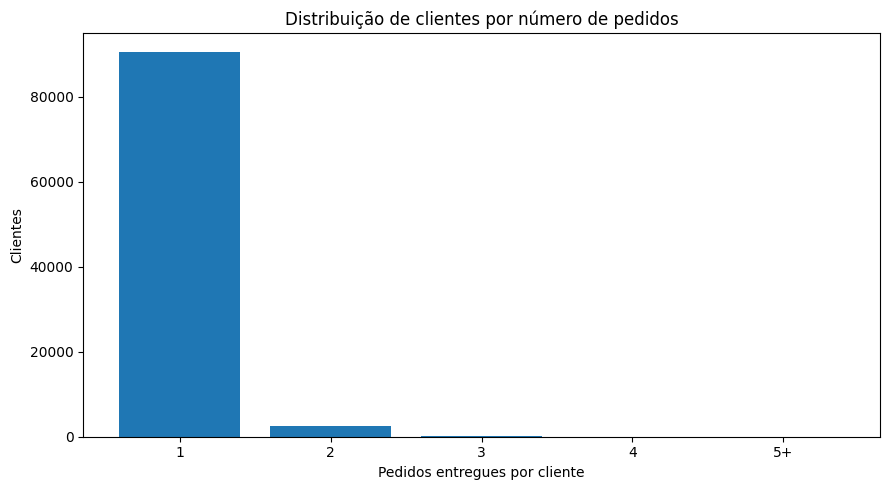

In [8]:
plot_freq = frequency_distribution.copy()
plot_freq["frequency_band"] = np.where(
    plot_freq["orders_per_customer"].ge(5), "5+", plot_freq["orders_per_customer"].astype(str)
)
plot_freq = (
    plot_freq.groupby("frequency_band", as_index=False)
    .agg(customers=("customers", "sum"))
)
order = [str(x) for x in range(1,5)] + ["5+"]
plot_freq["frequency_band"] = pd.Categorical(plot_freq["frequency_band"], order, ordered=True)
plot_freq = plot_freq.sort_values("frequency_band")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_freq["frequency_band"].astype(str), plot_freq["customers"])
ax.set_title("Distribuição de clientes por número de pedidos")
ax.set_xlabel("Pedidos entregues por cliente")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()


## 5. Distribuição de Recency, Frequency e Monetary

Frequency e Monetary tendem a ser assimétricos. Os gráficos abaixo preservam todos os clientes nos cálculos e usam apenas limites visuais quando necessário.


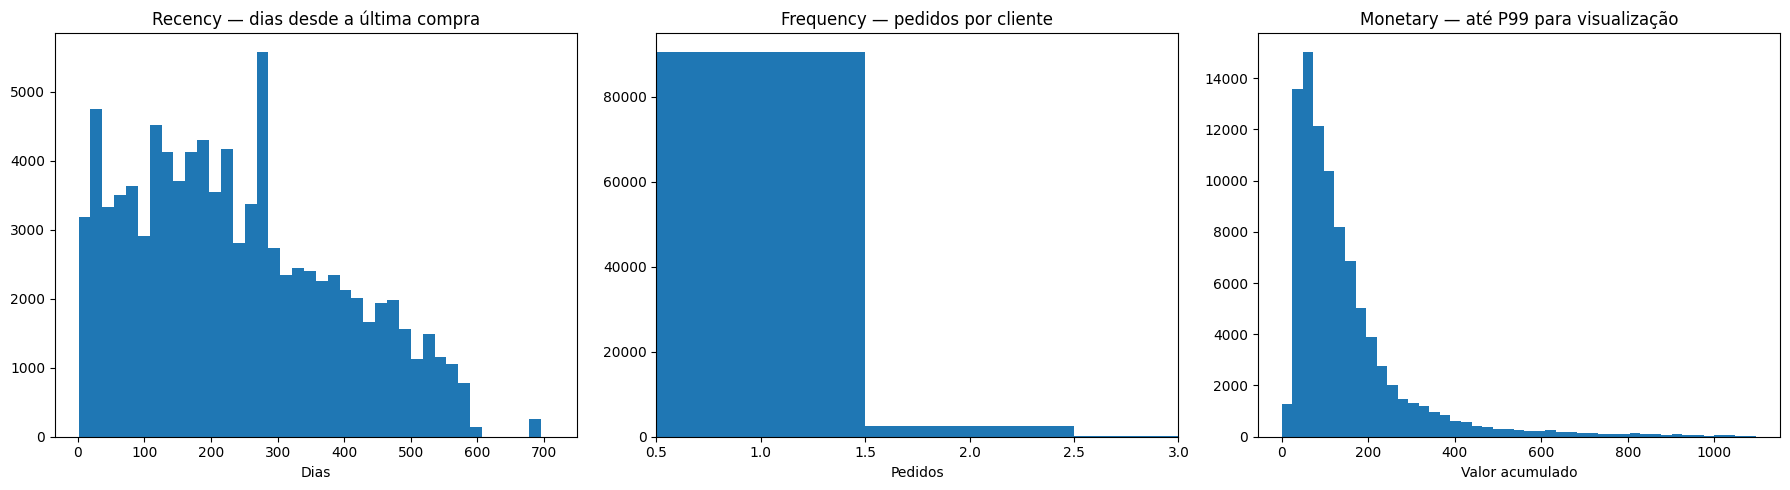

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["recency"], bins=40)
axes[0].set_title("Recency — dias desde a última compra")
axes[0].set_xlabel("Dias")

axes[1].hist(rfm["frequency"], bins=np.arange(0.5, rfm["frequency"].max() + 1.5, 1))
axes[1].set_xlim(0.5, min(rfm["frequency"].quantile(.995) + 1, 10))
axes[1].set_title("Frequency — pedidos por cliente")
axes[1].set_xlabel("Pedidos")

m99 = rfm["monetary"].quantile(.99)
axes[2].hist(rfm.loc[rfm["monetary"].le(m99), "monetary"], bins=45)
axes[2].set_title("Monetary — até P99 para visualização")
axes[2].set_xlabel("Valor acumulado")

plt.tight_layout()
plt.show()


## 6. Scores RFM — método adaptado à distribuição

### Recency e Monetary
Recebem notas de 1 a 5 por quintis relativos à base.

### Frequency
Não usamos `qcut` diretamente, porque clientes com o mesmo número de pedidos não devem receber notas distintas só para preencher quintis. O score segue faixas comportamentais transparentes:

- 1 pedido → F=1
- 2 pedidos → F=2
- 3 pedidos → F=3
- 4 pedidos → F=4
- 5+ pedidos → F=5

Essa regra mantém o significado de recorrência e torna a segmentação mais interpretável para negócio.


In [10]:
def quantile_score(series, higher_is_better=True):
    # rank(method="average", pct=True) preserva empates de forma consistente.
    pct = series.rank(method="average", pct=True)
    score = np.ceil(pct * 5).clip(1, 5).astype(int)
    if not higher_is_better:
        score = 6 - score
    return score

rfm["r_score"] = quantile_score(rfm["recency"], higher_is_better=False)
rfm["m_score"] = quantile_score(rfm["monetary"], higher_is_better=True)
rfm["f_score"] = rfm["frequency"].clip(upper=5).astype(int)

rfm["rfm_score"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)
rfm["rfm_total_score"] = rfm[["r_score", "f_score", "m_score"]].sum(axis=1)

score_diagnostics = pd.DataFrame({
    "r_score": rfm["r_score"].value_counts().sort_index(),
    "f_score": rfm["f_score"].value_counts().sort_index(),
    "m_score": rfm["m_score"].value_counts().sort_index(),
}).fillna(0).astype(int)
score_diagnostics


,r_score,f_score,m_score
1,18689,90557,18669
2,18700,2573,18669
3,18650,181,18677
4,18664,28,18668
5,18655,19,18675


## 7. Segmentação executiva

Os segmentos são definidos com regras mutuamente priorizadas. A lógica distingue explicitamente clientes novos/one-shot de clientes recorrentes e dá precedência a clientes valiosos em risco.

| Segmento | Leitura principal |
|---|---|
| Champions | Recentes, recorrentes e de alto valor |
| Loyal Customers | Recorrência ativa e valor relevante |
| Potential Loyalists | Recorrência inicial e boa recência |
| New High Value | Uma compra recente, mas ticket/valor elevado |
| New Customers | Uma compra recente e valor ainda baixo/médio |
| Promising | Compra única relativamente recente com algum potencial de valor |
| Need Attention | Engajamento esfriando |
| Can't Lose Them | Histórico muito relevante, mas afastado |
| At Risk | Algum valor/recorrência histórica e baixa recência |
| Hibernating | Baixo sinal de valor e baixa recência |


In [11]:
def assign_segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    freq = row["frequency"]

    if r <= 2 and f >= 3 and m >= 4:
        return "Can't Lose Them"
    if r >= 4 and f >= 3 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 2 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and freq >= 2:
        return "Potential Loyalists"
    if r >= 4 and freq == 1 and m >= 4:
        return "New High Value"
    if r >= 4 and freq == 1:
        return "New Customers"
    if r == 3 and freq == 1 and m >= 3:
        return "Promising"
    if r == 3 and (freq >= 2 or m >= 3):
        return "Need Attention"
    if r <= 2 and (freq >= 2 or m >= 4):
        return "At Risk"
    return "Hibernating"

segment_order = [
    "Champions", "Loyal Customers", "Potential Loyalists",
    "New High Value", "New Customers", "Promising", "Need Attention",
    "Can't Lose Them", "At Risk", "Hibernating"
]

rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

rfm["segment"].value_counts().reindex(segment_order).fillna(0).astype(int)


segment
Champions                116
Loyal Customers         1587
Potential Loyalists       74
New High Value         14394
New Customers          21724
Promising              10556
Need Attention            27
Can't Lose Them           62
At Risk                14737
Hibernating            30081
Name: count, dtype: int64

## 8. Perfil dos segmentos

A tabela consolida tamanho, receita, recorrência e ticket. Para decisão de investimento, dois eixos merecem atenção simultânea: **participação no valor** e **tamanho da audiência**.


In [12]:
segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        repeat_rate=("repeat_customer", "mean"),
        avg_customer_value=("monetary", "mean"),
        median_customer_value=("monetary", "median"),
        avg_order_value=("avg_order_value", "mean"),
    )
    .reset_index()
)
segment_summary["customer_share"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary["revenue_share"] = segment_summary["revenue"] / segment_summary["revenue"].sum()
segment_summary = segment_summary.sort_values("revenue", ascending=False)
segment_summary


,segment,customers,revenue,avg_recency,avg_frequency,repeat_rate,avg_customer_value,median_customer_value,avg_order_value,customer_share,revenue_share
8,At Risk,14737,"4,511,422.74",393.39,1.06,0.06,306.13,210.18,297.11,0.16,0.29
3,New High Value,14394,"4,349,727.10",91.83,1.00,0.00,302.19,204.25,302.19,0.15,0.28
5,Promising,10556,"2,328,363.07",220.75,1.00,0.00,220.57,159.82,220.57,0.11,0.15
9,Hibernating,30081,"2,049,679.46",352.13,1.00,0.00,68.14,65.00,68.14,0.32,0.13
4,New Customers,21724,"1,584,263.04",90.29,1.00,0.00,72.93,69.70,72.93,0.23,0.10
1,Loyal Customers,1587,"496,411.30",135.57,2.04,1.00,312.80,235.68,153.87,0.02,0.03
0,Champions,116,"66,351.90",91.21,3.54,1.00,572.00,439.35,163.07,0.00,0.00
7,Can't Lose Them,62,"29,233.07",370.45,3.08,1.00,471.50,355.68,152.79,0.00,0.00
2,Potential Loyalists,74,"5,059.87",86.46,2.00,1.00,68.38,68.90,34.19,0.00,0.00
6,Need Attention,27,"1,950.22",211.37,2.00,1.00,72.23,73.18,36.12,0.00,0.00


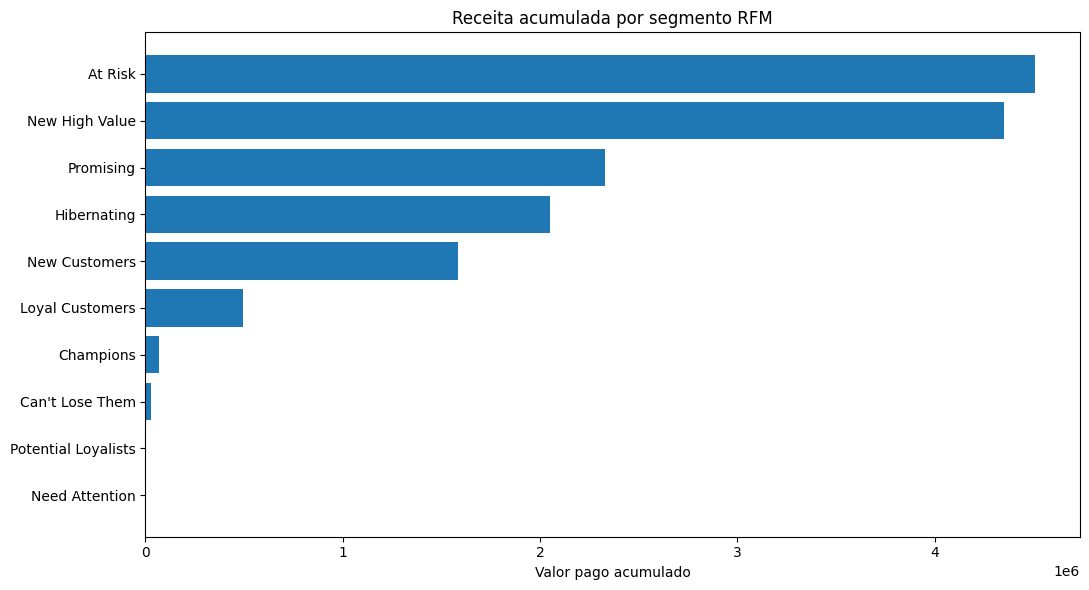

In [13]:
plot_df = segment_summary.sort_values("revenue", ascending=True)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(plot_df["segment"].astype(str), plot_df["revenue"])
ax.set_title("Receita acumulada por segmento RFM")
ax.set_xlabel("Valor pago acumulado")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


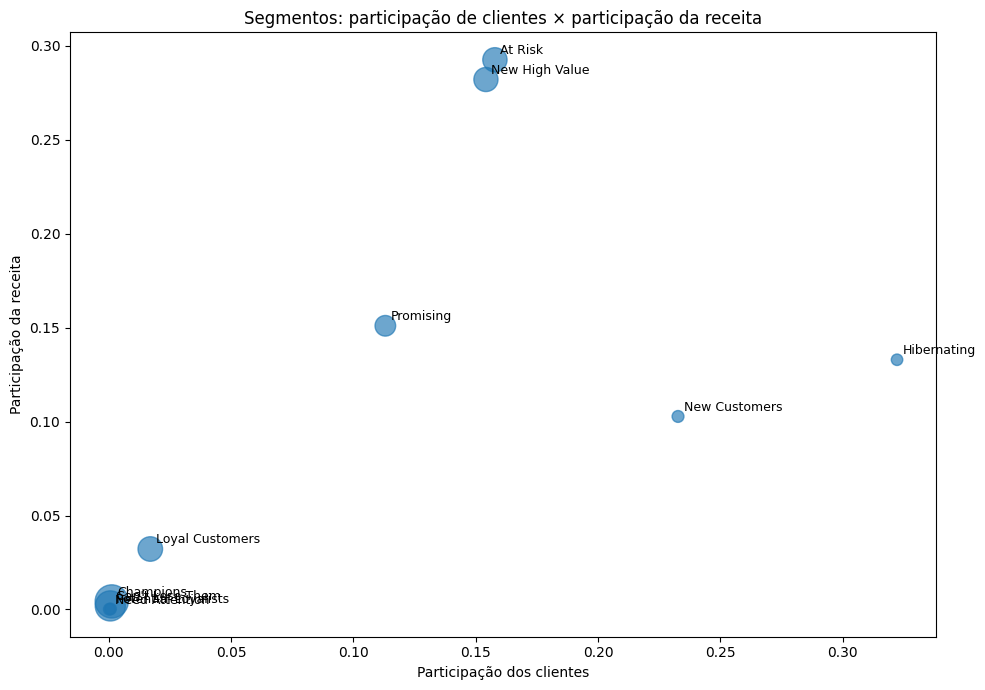

In [14]:
segment_scatter = segment_summary.loc[segment_summary["customers"].gt(0)].copy()
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    segment_scatter["customer_share"],
    segment_scatter["revenue_share"],
    s=np.maximum(segment_scatter["avg_customer_value"], 20),
    alpha=.65,
)
for _, row in segment_scatter.iterrows():
    ax.annotate(
        str(row["segment"]),
        (row["customer_share"], row["revenue_share"]),
        xytext=(4, 4), textcoords="offset points", fontsize=9
    )
ax.set_title("Segmentos: participação de clientes × participação da receita")
ax.set_xlabel("Participação dos clientes")
ax.set_ylabel("Participação da receita")
plt.tight_layout()
plt.show()


## 9. Concentração de receita e Pareto

A concentração mostra quão dependente o negócio é de uma fração pequena de consumidores. Isso ajuda a dimensionar tanto a oportunidade de fidelização quanto o risco de churn dos clientes de maior valor.


In [15]:
rfm_ranked = rfm.sort_values("monetary", ascending=False).reset_index(drop=True)
rfm_ranked["customer_rank"] = np.arange(1, len(rfm_ranked) + 1)
rfm_ranked["customer_share_cum"] = rfm_ranked["customer_rank"] / len(rfm_ranked)
rfm_ranked["revenue_cum"] = rfm_ranked["monetary"].cumsum()
rfm_ranked["revenue_share_cum"] = rfm_ranked["revenue_cum"] / rfm_ranked["monetary"].sum()

concentration_rows = []
for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]:
    n = max(1, int(np.ceil(len(rfm_ranked) * pct)))
    concentration_rows.append({
        "top_customer_share": pct,
        "customers": n,
        "revenue_share": rfm_ranked.loc[n - 1, "revenue_share_cum"],
    })
concentration = pd.DataFrame(concentration_rows)
concentration


,top_customer_share,customers,revenue_share
0,0.01,934,0.10
1,0.05,4668,0.27
2,0.10,9336,0.38
3,0.20,18672,0.54
4,0.30,28008,0.65
5,0.50,46679,0.81


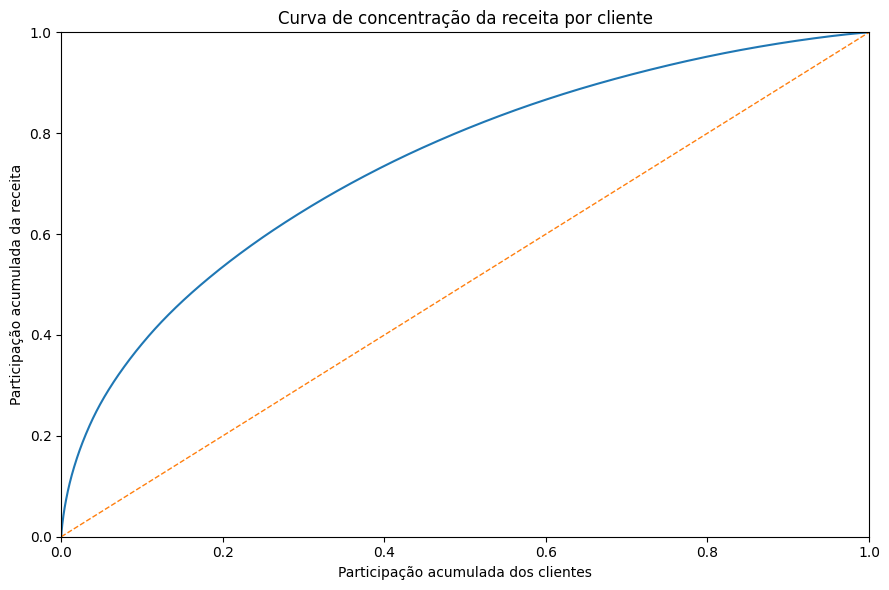

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(rfm_ranked["customer_share_cum"], rfm_ranked["revenue_share_cum"])
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("Curva de concentração da receita por cliente")
ax.set_xlabel("Participação acumulada dos clientes")
ax.set_ylabel("Participação acumulada da receita")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 10. Matriz Recency × Monetary

Como a maior parte dos consumidores pode ter apenas um pedido, a matriz **R × M** é especialmente útil para separar clientes de alto valor ainda recentes daqueles de alto valor que já esfriaram.


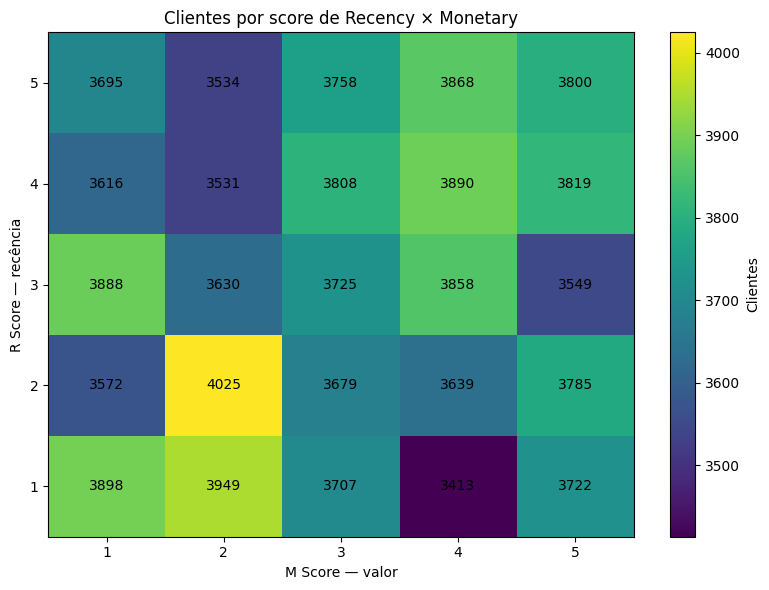

m_score,1,2,3,4,5
r_score,,,,,
5,3695,3534,3758,3868,3800
4,3616,3531,3808,3890,3819
3,3888,3630,3725,3858,3549
2,3572,4025,3679,3639,3785
1,3898,3949,3707,3413,3722


In [17]:
rm_matrix = (
    rfm.groupby(["r_score", "m_score"], as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum")
    )
)
rm_customers = rm_matrix.pivot(index="r_score", columns="m_score", values="customers")     .reindex(index=[5,4,3,2,1], columns=[1,2,3,4,5])

fig, ax = plt.subplots(figsize=(8, 6))
mat = rm_customers.fillna(0).to_numpy()
im = ax.imshow(mat, aspect="auto")
ax.set_xticks(range(len(rm_customers.columns)), rm_customers.columns)
ax.set_yticks(range(len(rm_customers.index)), rm_customers.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.0f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Clientes")
ax.set_title("Clientes por score de Recency × Monetary")
ax.set_xlabel("M Score — valor")
ax.set_ylabel("R Score — recência")
plt.tight_layout()
plt.show()

rm_customers


## 11. Matriz Frequency × Monetary

Essa matriz evidencia a diferença entre clientes de **alto ticket pontual** e clientes de **valor construído por recorrência**.


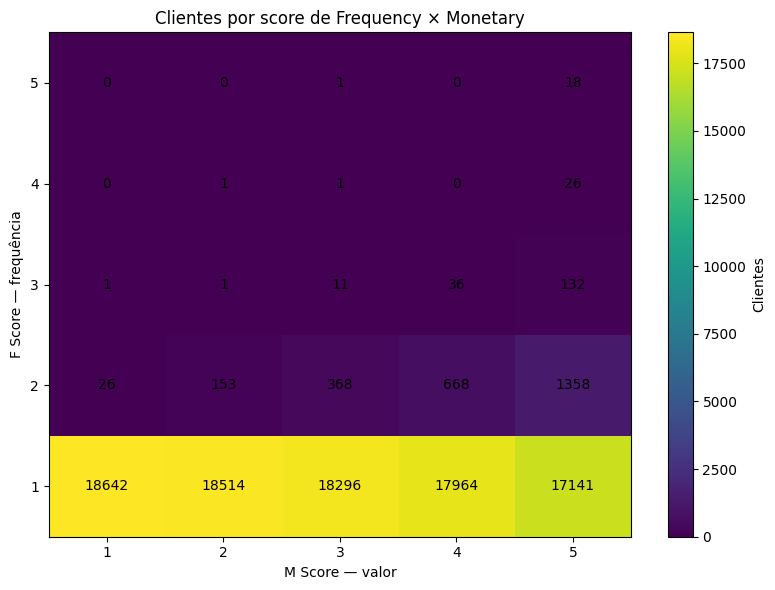

m_score,1,2,3,4,5
f_score,,,,,
5,NaN,NaN,1.00,NaN,18.00
4,NaN,1.00,1.00,NaN,26.00
3,1.00,1.00,11.00,36.00,132.00
2,26.00,153.00,368.00,668.00,"1,358.00"
1,"18,642.00","18,514.00","18,296.00","17,964.00","17,141.00"


In [18]:
fm_matrix = (
    rfm.groupby(["f_score", "m_score"], as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean")
    )
)
fm_customers = fm_matrix.pivot(index="f_score", columns="m_score", values="customers")     .reindex(index=[5,4,3,2,1], columns=[1,2,3,4,5])

fig, ax = plt.subplots(figsize=(8, 6))
mat = fm_customers.fillna(0).to_numpy()
im = ax.imshow(mat, aspect="auto")
ax.set_xticks(range(len(fm_customers.columns)), fm_customers.columns)
ax.set_yticks(range(len(fm_customers.index)), fm_customers.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.0f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Clientes")
ax.set_title("Clientes por score de Frequency × Monetary")
ax.set_xlabel("M Score — valor")
ax.set_ylabel("F Score — frequência")
plt.tight_layout()
plt.show()

fm_customers


## 12. Top clientes e clientes valiosos em risco

Um ranking de Monetary sozinho mistura clientes ativos com clientes possivelmente perdidos. Por isso, são produzidas duas listas: **top value** e **high-value at risk**.


In [19]:
top_customers = (
    rfm.sort_values(["monetary", "frequency"], ascending=[False, False])
    [[
        "customer_unique_id", "segment", "recency", "frequency", "monetary",
        "avg_order_value", "last_purchase", "rfm_score", "rfm_total_score"
    ]]
    .head(20)
)

top_customers


,customer_unique_id,segment,recency,frequency,monetary,avg_order_value,last_purchase,rfm_score,rfm_total_score
3724,0a0a92112bd4c708ca5fde585afaa872,At Risk,335,1,"13,664.08","13,664.08",2017-09-29 15:24:52,215,8
79636,da122df9eeddfedc1dc1f5349a1a690c,At Risk,516,2,"7,571.63","3,785.82",2017-04-01 15:58:41,125,8
43168,763c8b1c9c68a0229c42c9fc6f662b93,New High Value,46,1,"7,274.88","7,274.88",2018-07-15 14:49:44,515,11
80463,dc4802a71eae9be1dd28f5d788ceb526,At Risk,564,1,"6,929.31","6,929.31",2017-02-12 20:37:36,115,7
25436,459bef486812aa25204be022145caa62,New High Value,36,1,"6,922.21","6,922.21",2018-07-25 18:10:17,515,11
93081,ff4159b92c40ebe40454e3e6a7c35ed6,At Risk,463,1,"6,726.66","6,726.66",2017-05-24 18:14:34,115,7
23411,4007669dec559734d6f53e029e360987,At Risk,279,1,"6,081.54","6,081.54",2017-11-24 11:03:35,215,8
87148,eebb5dda148d3893cdaf5b5ca3040ccb,At Risk,499,1,"4,764.34","4,764.34",2017-04-18 18:50:13,115,7
26640,48e1ac109decbb87765a3eade6854098,New High Value,69,1,"4,681.78","4,681.78",2018-06-22 12:23:19,515,11
73127,c8460e4251689ba205045f3ea17884a1,Champions,22,4,"4,655.91","1,163.98",2018-08-08 14:27:15,545,14


In [20]:
high_value_at_risk = (
    rfm.loc[rfm["segment"].astype(str).isin(["Can't Lose Them", "At Risk"])]
    .sort_values(["monetary", "frequency"], ascending=[False, False])
    [[
        "customer_unique_id", "segment", "recency", "frequency",
        "monetary", "avg_order_value", "last_purchase"
    ]]
    .head(50)
)
high_value_at_risk.head(20)


,customer_unique_id,segment,recency,frequency,monetary,avg_order_value,last_purchase
3724,0a0a92112bd4c708ca5fde585afaa872,At Risk,335,1,"13,664.08","13,664.08",2017-09-29 15:24:52
79636,da122df9eeddfedc1dc1f5349a1a690c,At Risk,516,2,"7,571.63","3,785.82",2017-04-01 15:58:41
80463,dc4802a71eae9be1dd28f5d788ceb526,At Risk,564,1,"6,929.31","6,929.31",2017-02-12 20:37:36
93081,ff4159b92c40ebe40454e3e6a7c35ed6,At Risk,463,1,"6,726.66","6,726.66",2017-05-24 18:14:34
23411,4007669dec559734d6f53e029e360987,At Risk,279,1,"6,081.54","6,081.54",2017-11-24 11:03:35
87148,eebb5dda148d3893cdaf5b5ca3040ccb,At Risk,499,1,"4,764.34","4,764.34",2017-04-18 18:50:13
86890,edf81e1f3070b9dac83ec83dacdbb9bc,At Risk,499,1,"4,194.76","4,194.76",2017-04-18 20:37:26
34543,5e713be0853d8986528d7869a0811d2b,At Risk,572,1,"4,042.74","4,042.74",2017-02-04 18:54:15
416,011875f0176909c5cf0b14a9138bb691,At Risk,530,1,"4,016.91","4,016.91",2017-03-18 20:08:04
34048,5d09b0d82126457e2a8ebfb9c9a1ffc4,At Risk,566,1,"3,736.22","3,736.22",2017-02-10 10:19:22


## 13. RFM × meios de pagamento (opcional, usando output do Notebook 02)

Se `payment_behavior_order_level.csv` existir, o notebook cruza os tipos de pagamento usados em cada pedido com o segmento RFM do cliente.

> Um pedido pode usar mais de um tipo de pagamento. Portanto, a tabela abaixo mede **participação de pedidos associados a cada tipo**, e não uma decomposição exclusiva da receita.


In [21]:
payment_behavior_path = PROCESSED_DIR / "payment_behavior_order_level.csv"
payment_segment_mix = pd.DataFrame()

if payment_behavior_path.exists():
    payment_behavior = pd.read_csv(payment_behavior_path)

    expected_payment_cols = {"order_id", "payment_type"}
    if expected_payment_cols.issubset(payment_behavior.columns):
        order_customer_segment = orders_base.loc[
            orders_base["order_status"].eq("delivered"),
            ["order_id", "customer_unique_id"]
        ].merge(
            rfm[["customer_unique_id", "segment"]],
            on="customer_unique_id", how="inner", validate="many_to_one"
        )

        pay_seg = (
            payment_behavior[["order_id", "payment_type"]]
            .drop_duplicates()
            .merge(order_customer_segment, on="order_id", how="inner", validate="many_to_one")
        )

        payment_segment_mix = (
            pay_seg.groupby(["segment", "payment_type"], observed=False)
            .agg(orders=("order_id", "nunique"))
            .reset_index()
        )
        payment_segment_mix["segment_orders"] = (
            payment_segment_mix.groupby("segment", observed=False)["orders"].transform("sum")
        )
        payment_segment_mix["order_association_share"] = (
            payment_segment_mix["orders"] / payment_segment_mix["segment_orders"]
        )

        display(payment_segment_mix.sort_values(["segment", "orders"], ascending=[True, False]))
    else:
        print("Arquivo do Notebook 02 encontrado, mas sem as colunas order_id/payment_type esperadas.")
else:
    print("Output do Notebook 02 não encontrado; cruzamento de pagamentos será pulado.")


,segment,payment_type,orders,segment_orders,order_association_share
1,Champions,credit_card,320,421,0.76
0,Champions,boleto,79,421,0.19
3,Champions,voucher,21,421,0.05
2,Champions,debit_card,1,421,0.00
5,Loyal Customers,credit_card,2527,3309,0.76
4,Loyal Customers,boleto,578,3309,0.17
7,Loyal Customers,voucher,154,3309,0.05
6,Loyal Customers,debit_card,50,3309,0.02
9,Potential Loyalists,credit_card,106,155,0.68
8,Potential Loyalists,boleto,30,155,0.19


payment_type,boleto,credit_card,debit_card,voucher
segment,,,,
Champions,0.19,0.76,0.00,0.05
Loyal Customers,0.17,0.76,0.02,0.05
Potential Loyalists,0.19,0.68,0.05,0.08
New High Value,0.15,0.80,0.02,0.03
New Customers,0.20,0.74,0.02,0.04
Promising,0.18,0.77,0.01,0.03
Need Attention,0.12,0.61,0.05,0.21
Can't Lose Them,0.19,0.74,0.00,0.07
At Risk,0.18,0.78,0.01,0.03


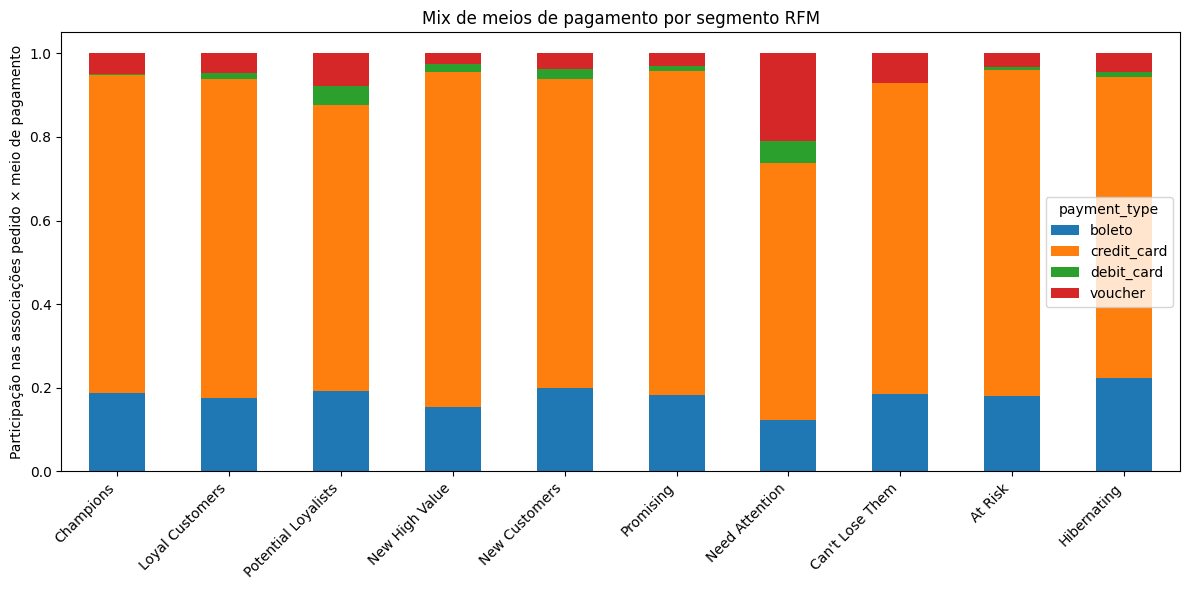

In [22]:
if not payment_segment_mix.empty:
    pay_pivot = payment_segment_mix.pivot(
        index="segment", columns="payment_type", values="order_association_share"
    ).fillna(0)
    display(pay_pivot)

    ax = pay_pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_title("Mix de meios de pagamento por segmento RFM")
    ax.set_xlabel("")
    ax.set_ylabel("Participação nas associações pedido × meio de pagamento")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 14. Recomendações por segmento

A segmentação transforma o histórico em uma lógica de alocação comercial.

| Segmento | Objetivo | Ação sugerida |
|---|---|---|
| Champions | Defender valor | Benefícios, cross-sell, early access, referrals |
| Loyal Customers | Expandir share of wallet | Recomendação personalizada e bundles |
| Potential Loyalists | Consolidar hábito | Incentivo à 3ª compra e comunicação pós-compra |
| New High Value | Converter ticket em recorrência | Onboarding premium e segunda compra rápida |
| New Customers | Ativar recompra | Jornada de onboarding e incentivo moderado |
| Promising | Desenvolver valor | Personalização por categoria e timing |
| Need Attention | Recuperar engajamento | Reativação leve e mensagem contextual |
| Can't Lose Them | Evitar perda de valor | Win-back prioritário e oferta seletiva |
| At Risk | Recuperar clientes historicamente bons | Testes de win-back com limite de CAC |
| Hibernating | Controlar custo | Comunicação barata; evitar subsídio indiscriminado |

### Implicação para investidores

Uma taxa de recorrência baixa aumenta a dependência de aquisição contínua. O RFM não prova causalidade, mas identifica onde a empresa possui base instalada com maior valor histórico e onde testes de retenção podem gerar retorno incremental.


## 15. KPIs executivos

Os indicadores abaixo são exportados em formato simples para reutilização no relatório e na apresentação.


In [23]:
total_revenue = rfm["monetary"].sum()
champions_revenue = rfm.loc[rfm["segment"].astype(str).eq("Champions"), "monetary"].sum()
risk_revenue = rfm.loc[
    rfm["segment"].astype(str).isin(["Can't Lose Them", "At Risk"]), "monetary"
].sum()

top10_share = concentration.loc[
    np.isclose(concentration["top_customer_share"], .10), "revenue_share"
].iloc[0]
top20_share = concentration.loc[
    np.isclose(concentration["top_customer_share"], .20), "revenue_share"
].iloc[0]

kpis = pd.DataFrame({
    "KPI": [
        "Clientes únicos",
        "Receita total considerada",
        "Valor médio por cliente",
        "Valor mediano por cliente",
        "Clientes recorrentes (2+ pedidos)",
        "Taxa de recorrência observada",
        "Receita de clientes recorrentes",
        "Receita — Champions",
        "Receita histórica — At Risk + Can't Lose Them",
        "Receita concentrada no Top 10%",
        "Receita concentrada no Top 20%",
    ],
    "Valor": [
        len(rfm), total_revenue, rfm["monetary"].mean(), rfm["monetary"].median(),
        repeat_customers, repeat_rate, repeat_revenue_share,
        champions_revenue / total_revenue if total_revenue else np.nan,
        risk_revenue / total_revenue if total_revenue else np.nan,
        top10_share, top20_share,
    ]
})
kpis


,KPI,Valor
0,Clientes únicos,"93,358.00"
1,Receita total considerada,"15,422,461.77"
2,Valor médio por cliente,165.20
3,Valor mediano por cliente,107.78
4,Clientes recorrentes (2+ pedidos),"2,801.00"
5,Taxa de recorrência observada,0.03
6,Receita de clientes recorrentes,0.06
7,Receita — Champions,0.00
8,Receita histórica — At Risk + Can't Lose Them,0.29
9,Receita concentrada no Top 10%,0.38


## 16. Sanity checks e governança

Os checks abaixo devem falhar explicitamente se houver quebra de granularidade ou inconsistência lógica. Eles tornam o pipeline mais seguro para reexecução.


In [24]:
assert rfm["customer_unique_id"].is_unique, "customer_rfm deve ter uma linha por customer_unique_id"
assert rfm["frequency"].ge(1).all(), "Frequency inválida"
assert rfm["recency"].ge(0).all(), "Recency negativa"
assert rfm["monetary"].ge(0).all(), "Monetary negativo"
assert rfm["r_score"].between(1, 5).all()
assert rfm["f_score"].between(1, 5).all()
assert rfm["m_score"].between(1, 5).all()
assert np.isclose(segment_summary["revenue"].sum(), rfm["monetary"].sum())
assert np.isclose(segment_summary["customers"].sum(), len(rfm))

print("Sanity checks concluídos com sucesso.")


Sanity checks concluídos com sucesso.


## 17. Exportação das camadas analíticas

Outputs principais:

- `customer_rfm.csv`: dimensão de cliente com métricas, scores e segmento;
- `rfm_segment_summary.csv`: visão executiva por segmento;
- `rfm_frequency_distribution.csv`: distribuição de pedidos por cliente;
- `rfm_revenue_concentration.csv`: Pareto/concentração;
- `rfm_top_customers.csv`: maiores clientes por valor;
- `rfm_high_value_at_risk.csv`: clientes valiosos em risco;
- `rfm_executive_kpis.csv`: KPIs para relatório/apresentação;
- `rfm_payment_segment_mix.csv`: mix de pagamento por segmento, quando disponível.


In [25]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

exports = {
    "customer_rfm.csv": rfm,
    "rfm_segment_summary.csv": segment_summary,
    "rfm_frequency_distribution.csv": frequency_distribution,
    "rfm_revenue_concentration.csv": concentration,
    "rfm_top_customers.csv": top_customers,
    "rfm_high_value_at_risk.csv": high_value_at_risk,
    "rfm_executive_kpis.csv": kpis,
    "rfm_rm_matrix.csv": rm_matrix,
    "rfm_fm_matrix.csv": fm_matrix,
}
if not payment_segment_mix.empty:
    exports["rfm_payment_segment_mix.csv"] = payment_segment_mix

for filename, df in exports.items():
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False)
    print("Salvo:", path)


Salvo: ../data/processed/customer_rfm.csv
Salvo: ../data/processed/rfm_segment_summary.csv
Salvo: ../data/processed/rfm_frequency_distribution.csv
Salvo: ../data/processed/rfm_revenue_concentration.csv
Salvo: ../data/processed/rfm_top_customers.csv
Salvo: ../data/processed/rfm_high_value_at_risk.csv
Salvo: ../data/processed/rfm_executive_kpis.csv
Salvo: ../data/processed/rfm_rm_matrix.csv
Salvo: ../data/processed/rfm_fm_matrix.csv
Salvo: ../data/processed/rfm_payment_segment_mix.csv


## 18. Checklist de interpretação

### O que este notebook mede bem

- valor histórico no nível do consumidor real (`customer_unique_id`);
- recorrência observada dentro da janela do dataset;
- concentração de receita;
- recência e risco comportamental;
- segmentos de clientes para priorização comercial.

### Limitações

1. **RFM é descritivo e relativo ao período observado.** Não estima causalmente a probabilidade de recompra.
2. **Monetary é receita paga, não margem.** Não há CAC, custo de produto ou custo promocional no dataset.
3. **Clientes adquiridos perto do fim da janela têm menos tempo para recomprar.** A análise de coorte é necessária para comparar retenção de forma justa.
4. **Recorrência observada não é retenção ajustada por exposição.** Isso será tratado no Notebook 04/05.
5. **Segmentos são regras de negócio.** Devem ser validados com testes de campanha e, depois, comparados com um modelo de propensão.

### Próxima etapa

O Notebook 04 deve decompor a recompra por tempo desde a primeira compra, categoria, ticket e pagamento. O Notebook 05 deve construir coortes mensais para separar efeito de aquisição recente de retenção real.
